## Section 1: Data Loading and Historical Aggregation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import gc
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Change this path for Kaggle vs local
DATA_PATH = 'home-credit-default-risk/'
# DATA_PATH = 'home-credit-default-risk/'  # uncomment for local
print('Libraries loaded. DATA_PATH =', DATA_PATH)


Libraries loaded. DATA_PATH = home-credit-default-risk/


### 1.1 Load All CSV Files


In [2]:
app_train = pd.read_csv(DATA_PATH + 'application_train.csv')
app_test  = pd.read_csv(DATA_PATH + 'application_test.csv')
bureau    = pd.read_csv(DATA_PATH + 'bureau.csv')
bureau_bal= pd.read_csv(DATA_PATH + 'bureau_balance.csv')
pos       = pd.read_csv(DATA_PATH + 'POS_CASH_balance.csv')
cc        = pd.read_csv(DATA_PATH + 'credit_card_balance.csv')
prev      = pd.read_csv(DATA_PATH + 'previous_application.csv')
instal    = pd.read_csv(DATA_PATH + 'installments_payments.csv')

datasets = [('application_train', app_train), ('application_test', app_test),
            ('bureau', bureau), ('bureau_balance', bureau_bal),
            ('POS_CASH_balance', pos), ('credit_card_balance', cc),
            ('previous_application', prev), ('installments_payments', instal)]

print('=== Dataset Shapes ===')
for name, df in datasets:
    print(f'{name}: {df.shape}')


=== Dataset Shapes ===
application_train: (307511, 122)
application_test: (48744, 121)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
POS_CASH_balance: (10001358, 8)
credit_card_balance: (3840312, 23)
previous_application: (1670214, 37)
installments_payments: (13605401, 8)


### 1.2 Bureau Aggregation (prefix BUREAU_)


In [3]:
num_cols = ['DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'AMT_CREDIT_SUM',
            'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_OVERDUE', 'AMT_ANNUITY']

agg_dict = {}
for col in num_cols:
    agg_dict[col] = ['mean', 'min', 'max']
agg_dict['SK_ID_BUREAU'] = 'count'

bureau_agg = bureau.groupby('SK_ID_CURR').agg(agg_dict).reset_index()
bureau_agg.columns = ['SK_ID_CURR'] + [f'BUREAU_{col}_{stat}' for col in num_cols for stat in ['mean','min','max']] + ['BUREAU_count']

# Count Active and Closed
bureau_active = bureau[bureau['CREDIT_ACTIVE']=='Active'].groupby('SK_ID_CURR').size().reset_index(name='BUREAU_ACTIVE_count')
bureau_closed = bureau[bureau['CREDIT_ACTIVE']=='Closed'].groupby('SK_ID_CURR').size().reset_index(name='BUREAU_CLOSED_count')
bureau_agg = bureau_agg.merge(bureau_active, on='SK_ID_CURR', how='left')
bureau_agg = bureau_agg.merge(bureau_closed, on='SK_ID_CURR', how='left')
bureau_agg['BUREAU_ACTIVE_count'] = bureau_agg['BUREAU_ACTIVE_count'].fillna(0).astype(int)
bureau_agg['BUREAU_CLOSED_count'] = bureau_agg['BUREAU_CLOSED_count'].fillna(0).astype(int)

print('Bureau aggregated:', bureau_agg.shape)


Bureau aggregated: (305811, 22)


### 1.3 Bureau Balance Aggregation (prefix BURO_BAL_)


In [4]:
# Join bureau_balance to bureau to get SK_ID_CURR
bureau_bal_map = bureau_bal.merge(bureau[['SK_ID_BUREAU','SK_ID_CURR']], on='SK_ID_BUREAU', how='left')

# Count of balance records per SK_ID_CURR
buro_bal_count = bureau_bal_map.groupby('SK_ID_CURR').size().reset_index(name='BURO_BAL_count')

# STATUS value counts as percentages
status_dummies = pd.get_dummies(bureau_bal_map['STATUS'], prefix='status')
status_dummies['SK_ID_CURR'] = bureau_bal_map['SK_ID_CURR'].values
status_pct = status_dummies.groupby('SK_ID_CURR').mean().reset_index()
status_pct.columns = ['SK_ID_CURR'] + [f'BURO_BAL_{c}' for c in status_pct.columns[1:]]

buro_bal_agg = buro_bal_count.merge(status_pct, on='SK_ID_CURR', how='left')

print('Bureau Balance aggregated:', buro_bal_agg.shape)
del bureau_bal, bureau_bal_map, buro_bal_count, status_dummies, status_pct, bureau, bureau_active, bureau_closed; gc.collect()


Bureau Balance aggregated: (134542, 10)


0

### 1.4 POS CASH Balance Aggregation (prefix POS_)


In [5]:
pos_agg = pos.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE': ['count', 'mean', 'max'],
    'SK_DPD': ['mean', 'max'],
    'SK_DPD_DEF': ['mean'],
    'CNT_INSTALMENT': ['mean', 'max'],
    'CNT_INSTALMENT_FUTURE': ['mean', 'max']
}).reset_index()

pos_agg.columns = ['SK_ID_CURR'] + [
    'POS_MONTHS_BALANCE_count', 'POS_MONTHS_BALANCE_mean', 'POS_MONTHS_BALANCE_max',
    'POS_SK_DPD_mean', 'POS_SK_DPD_max',
    'POS_SK_DPD_DEF_mean',
    'POS_CNT_INSTALMENT_mean', 'POS_CNT_INSTALMENT_max',
    'POS_CNT_INSTALMENT_FUTURE_mean', 'POS_CNT_INSTALMENT_FUTURE_max'
]

print('POS CASH aggregated:', pos_agg.shape)
del pos; gc.collect()


POS CASH aggregated: (337252, 11)


0

### 1.5 Credit Card Balance Aggregation (prefix CC_)


In [6]:
cc_agg = cc.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE': ['mean', 'max'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean', 'max'],
    'AMT_DRAWINGS_ATM_CURRENT': ['mean'],
    'AMT_DRAWINGS_CURRENT': ['mean'],
    'AMT_PAYMENT_CURRENT': ['mean'],
    'SK_DPD': ['mean', 'max'],
    'SK_ID_PREV': 'count'
}).reset_index()

cc_agg.columns = ['SK_ID_CURR'] + [
    'CC_AMT_BALANCE_mean', 'CC_AMT_BALANCE_max',
    'CC_AMT_CREDIT_LIMIT_ACTUAL_mean', 'CC_AMT_CREDIT_LIMIT_ACTUAL_max',
    'CC_AMT_DRAWINGS_ATM_CURRENT_mean',
    'CC_AMT_DRAWINGS_CURRENT_mean',
    'CC_AMT_PAYMENT_CURRENT_mean',
    'CC_SK_DPD_mean', 'CC_SK_DPD_max',
    'CC_count'
]

print('Credit Card aggregated:', cc_agg.shape)
del cc; gc.collect()


Credit Card aggregated: (103558, 11)


0

### 1.6 Previous Application Aggregation (prefix PREV_)


In [7]:
prev_agg = prev.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'AMT_APPLICATION': 'mean',
    'AMT_CREDIT': 'mean',
    'AMT_ANNUITY': 'mean',
    'AMT_GOODS_PRICE': 'mean'
}).reset_index()

prev_agg.columns = ['SK_ID_CURR', 'PREV_count', 'PREV_AMT_APPLICATION_mean',
                     'PREV_AMT_CREDIT_mean', 'PREV_AMT_ANNUITY_mean', 'PREV_AMT_GOODS_PRICE_mean']

# Count Approved and Refused
prev_approved = prev[prev['NAME_CONTRACT_STATUS']=='Approved'].groupby('SK_ID_CURR').size().reset_index(name='PREV_Approved_count')
prev_refused  = prev[prev['NAME_CONTRACT_STATUS']=='Refused'].groupby('SK_ID_CURR').size().reset_index(name='PREV_Refused_count')
prev_agg = prev_agg.merge(prev_approved, on='SK_ID_CURR', how='left')
prev_agg = prev_agg.merge(prev_refused, on='SK_ID_CURR', how='left')
prev_agg['PREV_Approved_count'] = prev_agg['PREV_Approved_count'].fillna(0).astype(int)
prev_agg['PREV_Refused_count']  = prev_agg['PREV_Refused_count'].fillna(0).astype(int)

print('Previous Application aggregated:', prev_agg.shape)
del prev, prev_approved, prev_refused; gc.collect()


Previous Application aggregated: (338857, 8)


0

### 1.7 Installments Payments Aggregation (prefix INSTAL_)


In [8]:
instal['PAYMENT_DIFF'] = instal['AMT_PAYMENT'] - instal['AMT_INSTALMENT']
instal['DAYS_DIFF'] = instal['DAYS_ENTRY_PAYMENT'] - instal['DAYS_INSTALMENT']
instal['LATE'] = (instal['DAYS_DIFF'] > 0).astype(int)

instal_agg = instal.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'PAYMENT_DIFF': ['mean', 'max', 'sum'],
    'DAYS_DIFF': ['mean', 'max'],
    'LATE': 'sum'
}).reset_index()

instal_agg.columns = ['SK_ID_CURR', 'INSTAL_count',
                       'INSTAL_PAYMENT_DIFF_mean', 'INSTAL_PAYMENT_DIFF_max', 'INSTAL_PAYMENT_DIFF_sum',
                       'INSTAL_DAYS_DIFF_mean', 'INSTAL_DAYS_DIFF_max',
                       'INSTAL_LATE_PAYMENT_count']
instal_agg['INSTAL_LATE_PAYMENT_count'] = instal_agg['INSTAL_LATE_PAYMENT_count'].astype(int)

print('Installments aggregated:', instal_agg.shape)
del instal; gc.collect()


Installments aggregated: (339587, 8)


0

### 1.8 Merge All Aggregated Features onto Train/Test


In [9]:
agg_dfs = [bureau_agg, buro_bal_agg, pos_agg, cc_agg, prev_agg, instal_agg]

train = app_train.copy()
test  = app_test.copy()

for agg_df in agg_dfs:
    train = train.merge(agg_df, on='SK_ID_CURR', how='left')
    test  = test.merge(agg_df, on='SK_ID_CURR', how='left')

print(f'Train after merge: {train.shape}')
print(f'Test  after merge: {test.shape}')

del app_train, app_test, bureau_agg, buro_bal_agg, pos_agg, cc_agg, prev_agg, instal_agg, agg_dfs
gc.collect()


Train after merge: (307511, 186)
Test  after merge: (48744, 185)


0

## Section 2: Data Preprocessing

Handle missing values, imputation, and outlier detection.


### 2.1 Missing Values Summary


In [10]:
missing_pct = train.isnull().mean().sort_values(ascending=False) * 100
missing_df = pd.DataFrame({'column': missing_pct.index, 'pct_missing': missing_pct.values})
print('=== Columns with missing values (>0%) ===')
print(missing_df[missing_df['pct_missing'] > 0].to_string(index=False))
print(f'\nTotal columns: {train.shape[1]}')
print(f'Columns with any missing: {(missing_pct > 0).sum()}')


=== Columns with missing values (>0%) ===
                            column  pct_missing
       CC_AMT_PAYMENT_CURRENT_mean    80.143800
  CC_AMT_DRAWINGS_ATM_CURRENT_mean    80.117784
           BUREAU_AMT_ANNUITY_mean    73.981744
            BUREAU_AMT_ANNUITY_min    73.981744
            BUREAU_AMT_ANNUITY_max    73.981744
                CC_AMT_BALANCE_max    71.739222
      CC_AMT_DRAWINGS_CURRENT_mean    71.739222
                    CC_SK_DPD_mean    71.739222
               CC_AMT_BALANCE_mean    71.739222
                          CC_count    71.739222
                     CC_SK_DPD_max    71.739222
   CC_AMT_CREDIT_LIMIT_ACTUAL_mean    71.739222
    CC_AMT_CREDIT_LIMIT_ACTUAL_max    71.739222
                 BURO_BAL_status_3    70.007252
                    BURO_BAL_count    70.007252
                 BURO_BAL_status_5    70.007252
                 BURO_BAL_status_X    70.007252
                 BURO_BAL_status_C    70.007252
                 BURO_BAL_status_4    70.00725

### 2.2 Drop Columns with >= 30% Missing


In [11]:
cols_to_drop = missing_pct[missing_pct >= 30].index.tolist()
print(f'Dropping {len(cols_to_drop)} columns with >= 30% missing values:')
for c in cols_to_drop:
    print(f'  {c}: {missing_pct[c]:.1f}%')

train.drop(columns=cols_to_drop, inplace=True, errors='ignore')
test.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f'\nTrain after drop: {train.shape}')
print(f'Test  after drop: {test.shape}')


Dropping 72 columns with >= 30% missing values:
  CC_AMT_PAYMENT_CURRENT_mean: 80.1%
  CC_AMT_DRAWINGS_ATM_CURRENT_mean: 80.1%
  BUREAU_AMT_ANNUITY_mean: 74.0%
  BUREAU_AMT_ANNUITY_min: 74.0%
  BUREAU_AMT_ANNUITY_max: 74.0%
  CC_AMT_BALANCE_max: 71.7%
  CC_AMT_DRAWINGS_CURRENT_mean: 71.7%
  CC_SK_DPD_mean: 71.7%
  CC_AMT_BALANCE_mean: 71.7%
  CC_count: 71.7%
  CC_SK_DPD_max: 71.7%
  CC_AMT_CREDIT_LIMIT_ACTUAL_mean: 71.7%
  CC_AMT_CREDIT_LIMIT_ACTUAL_max: 71.7%
  BURO_BAL_status_3: 70.0%
  BURO_BAL_count: 70.0%
  BURO_BAL_status_5: 70.0%
  BURO_BAL_status_X: 70.0%
  BURO_BAL_status_C: 70.0%
  BURO_BAL_status_4: 70.0%
  BURO_BAL_status_1: 70.0%
  BURO_BAL_status_2: 70.0%
  BURO_BAL_status_0: 70.0%
  COMMONAREA_MEDI: 69.9%
  COMMONAREA_MODE: 69.9%
  COMMONAREA_AVG: 69.9%
  NONLIVINGAPARTMENTS_AVG: 69.4%
  NONLIVINGAPARTMENTS_MODE: 69.4%
  NONLIVINGAPARTMENTS_MEDI: 69.4%
  FONDKAPREMONT_MODE: 68.4%
  LIVINGAPARTMENTS_AVG: 68.4%
  LIVINGAPARTMENTS_MEDI: 68.4%
  LIVINGAPARTMENTS_MODE: 68.4%


### 2.3 Fill Missing Values


In [12]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

# Remove TARGET from fill lists if present
if 'TARGET' in num_cols:
    num_cols.remove('TARGET')

print(f'Filling {len(num_cols)} numerical columns with median')
print(f'Filling {len(cat_cols)} categorical columns with mode')

for col in num_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

for col in cat_cols:
    if train[col].mode().shape[0] > 0:
        mode_val = train[col].mode()[0]
        train[col] = train[col].fillna(mode_val)
        test[col] = test[col].fillna(mode_val)

print(f'\nRemaining missing in train: {train.isnull().sum().sum()}')
print(f'Remaining missing in test:  {test.isnull().sum().sum()}')


Filling 102 numerical columns with median
Filling 11 categorical columns with mode

Remaining missing in train: 0
Remaining missing in test:  0


### 2.4 Outlier Detection (IQR Method)


In [13]:
outlier_summary = []
bounds_dict = {}  # simpan batas lower/upper tiap fitur

for feat in num_cols:
    Q1 = train[feat].quantile(0.25)
    Q3 = train[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((train[feat] < lower) | (train[feat] > upper)).sum()
    pct = n_outliers / len(train) * 100
    outlier_summary.append([feat, n_outliers, pct])
    bounds_dict[feat] = (lower, upper)

# Buat DataFrame ringkasan
outlier_df = pd.DataFrame(outlier_summary, columns=['Feature', 'Outliers', 'Percentage'])

# Urutkan dan ambil 10 terbesar
top10_outliers = outlier_df.sort_values(by='Outliers', ascending=False).head(10)
print(top10_outliers)

# ================================
# WINSORIZING
# ================================
# Hanya winsorize fitur yang memang punya outlier (Outliers > 0)
features_to_winsorize = outlier_df[outlier_df['Outliers'] > 0]['Feature'].tolist()

print(f"\nJumlah fitur yang akan di-winsorize: {len(features_to_winsorize)}")
print(features_to_winsorize)

for feat in features_to_winsorize:
    lower, upper = bounds_dict[feat]
    train[feat] = train[feat].clip(lower=lower, upper=upper)

                        Feature  Outliers  Percentage
18         REGION_RATING_CLIENT     80527   26.186706
19  REGION_RATING_CLIENT_W_CITY     78027   25.373726
98      INSTAL_PAYMENT_DIFF_sum     77933   25.343158
96     INSTAL_PAYMENT_DIFF_mean     75574   24.576031
8                 DAYS_EMPLOYED     72217   23.484363
25       REG_CITY_NOT_WORK_CITY     70867   23.045354
13              FLAG_WORK_PHONE     61308   19.936848
12               FLAG_EMP_PHONE     55386   18.011063
26      LIVE_CITY_NOT_WORK_CITY     55215   17.955455
81              POS_SK_DPD_mean     54683   17.782453

Jumlah fitur yang akan di-winsorize: 95
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGIO

### 2.5 Duplicate Row Check

In [14]:
train.duplicated().sum()

np.int64(0)

## Section 3: Exploratory Data Analysis (EDA)

Visualizations to understand the data and relationships with the TARGET variable.


### 3.1 TARGET Distribution

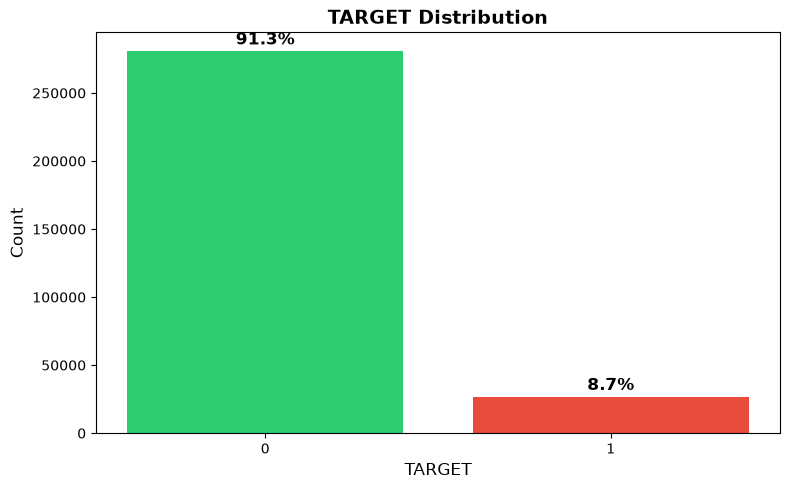

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
target_counts = train['TARGET'].value_counts()
target_pct = train['TARGET'].value_counts(normalize=True) * 100

bars = ax.bar(target_counts.index.astype(str), target_counts.values, color=['#2ecc71','#e74c3c'])
ax.set_xlabel('TARGET', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('TARGET Distribution', fontsize=14, fontweight='bold')

for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


The target variable is highly imbalanced. Most applicants repay their loans on time (TARGET=0),
while only a small fraction default (TARGET=1). This class imbalance must be addressed during modeling,
e.g., via class weights, oversampling (SMOTE), or appropriate evaluation metrics (AUC-ROC, F1).

### 3.2 Correlation Heatmap: Top 15 Features Most Correlated with TARGET

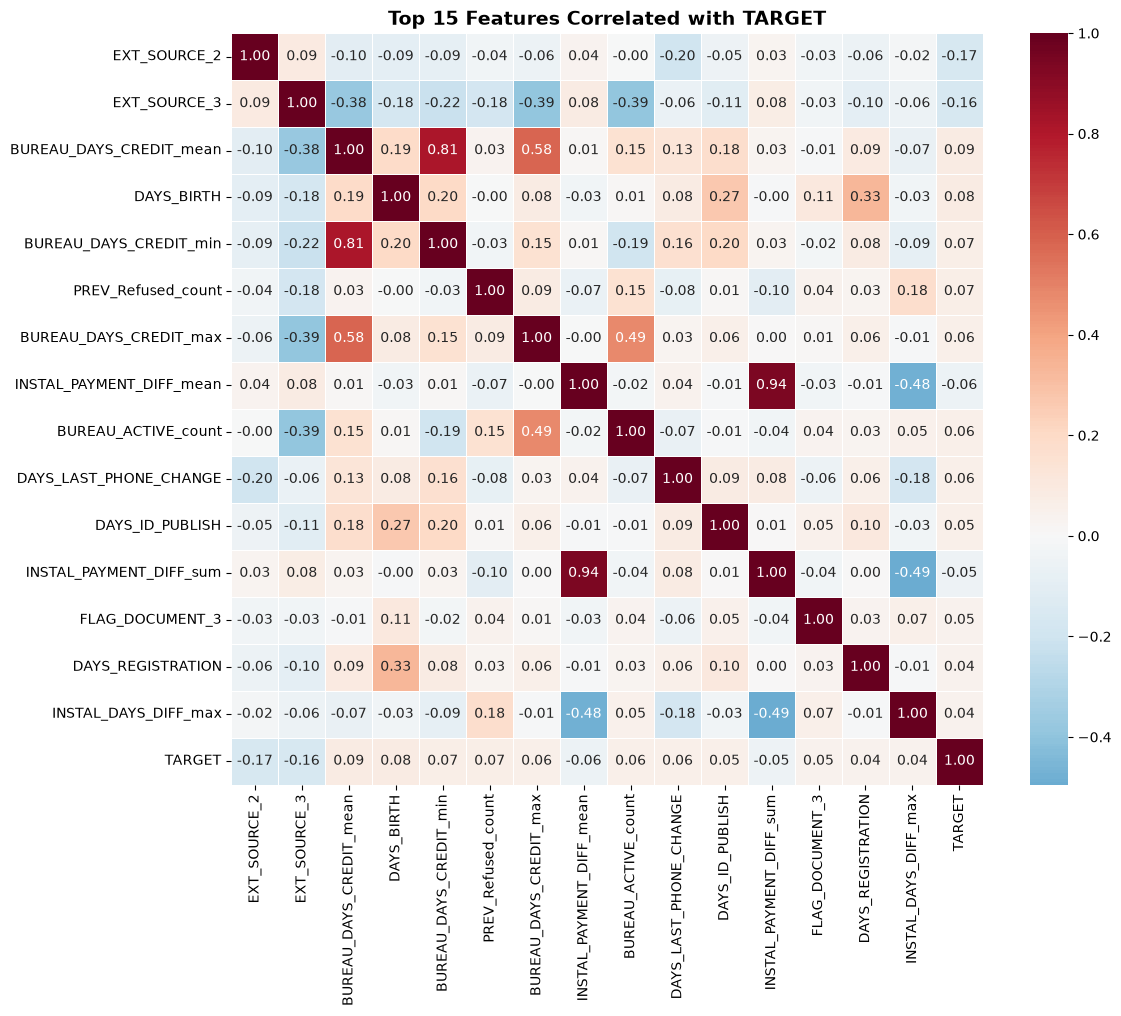

In [16]:
numeric_train = train.select_dtypes(include=[np.number])
corr_with_target = numeric_train.corr()['TARGET'].abs().sort_values(ascending=False)

# Exclude TARGET itself
top_features = corr_with_target.drop('TARGET').head(15).index.tolist()
top_features_with_target = top_features + ['TARGET']

corr_matrix = numeric_train[top_features_with_target].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Top 15 Features Correlated with TARGET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


The external source features (EXT_SOURCE_2/3) typically show the strongest negative correlation with TARGET,
meaning higher external scores are associated with lower default risk. Other features like DAYS_BIRTH,
and aggregated bureau/installment features also show meaningful correlations.


### 3.3 EXT_SOURCE Features Distribution by TARGET (KDE Plots)


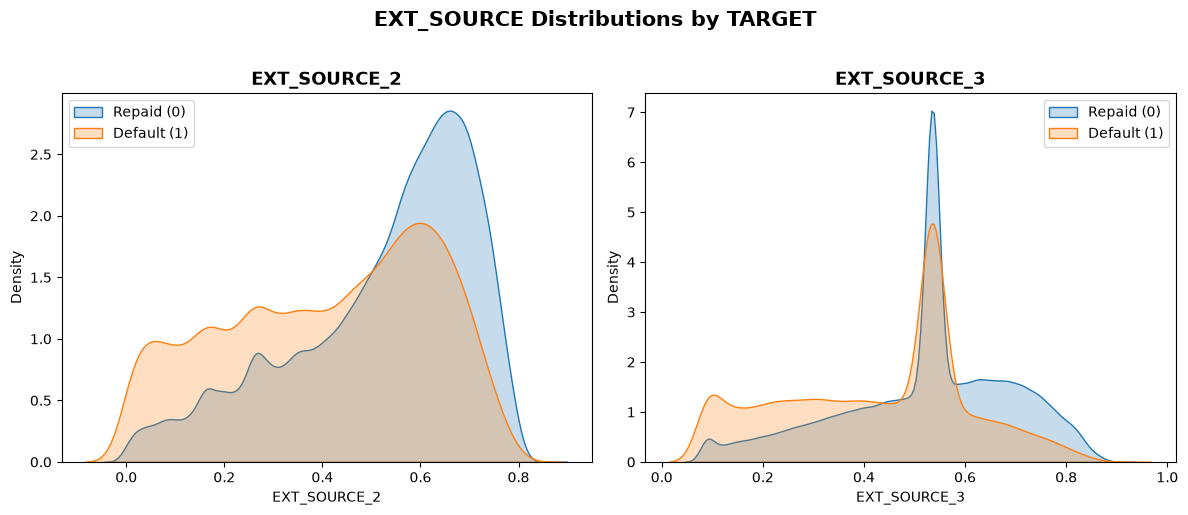

In [17]:
ext_cols = [c for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3'] if c in train.columns]

fig, axes = plt.subplots(1, len(ext_cols), figsize=(6*len(ext_cols), 5))
if len(ext_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, ext_cols):
    for t in [0, 1]:
        subset = train[train['TARGET']==t][col].dropna()
        label = 'Repaid (0)' if t == 0 else 'Default (1)'
        sns.kdeplot(subset, ax=ax, label=label, shade=True)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('EXT_SOURCE Distributions by TARGET', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


The EXT_SOURCE features show clear separation between default and non-default groups.
Defaulters (TARGET=1) tend to have lower EXT_SOURCE values, confirming these are among
the most predictive features in the dataset.

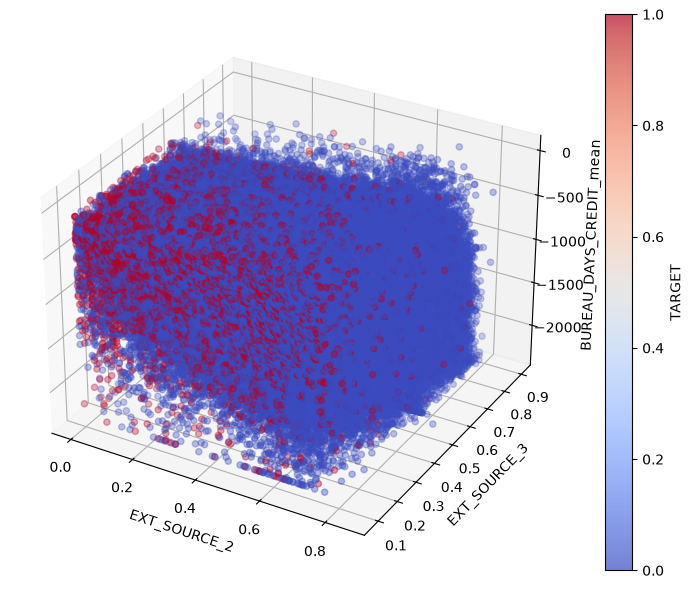

In [18]:
from mpl_toolkits.mplot3d import Axes3D

# Buat figure dan axis 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 3D
sc = ax.scatter(
    train['EXT_SOURCE_2'],   # X-axis
    train['EXT_SOURCE_3'],   # Y-axis
    train['BUREAU_DAYS_CREDIT_mean'],   # Z-axis
    c=train['TARGET'],       # Warna berdasarkan TARGET
    cmap='coolwarm',         # Pilihan colormap
    alpha=0.7
)

# Label axis
ax.set_xlabel('EXT_SOURCE_2')
ax.set_ylabel('EXT_SOURCE_3')
ax.set_zlabel('BUREAU_DAYS_CREDIT_mean')

# Tambahkan legend/warna
plt.colorbar(sc, label='TARGET')

fig.tight_layout()
plt.show()

**Early Detection of Late-Payment Risk**
<br>
Low external credit scores correlate strongly with payment problems early in the loan tenor. This makes external scores an effective early warning system for new loan applications.

**Limitations of Credit Bureau History**
<br>
A long credit history does not guarantee payment discipline on a new loan. Past credit experience alone is not a strong enough predictor of early-tenor repayment behavior.

## Section 4: Feature Engineering


### 4.1 Feature Encoding

- **Binary categoricals** (2 unique values) → Label Encoding
- **Low-cardinality multi-class categoricals** (3–10 unique) → One-Hot Encoding
- **High-cardinality categoricals** (>10 unique) → Label Encoding to avoid dimensionality explosion
- Train and test columns are aligned after encoding.


In [20]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder

# Store SK_ID_CURR before encoding (needed for submission)
train_ids = train['SK_ID_CURR'].copy()
test_ids  = test['SK_ID_CURR'].copy()

# Identify categorical columns (exclude SK_ID_CURR and TARGET)
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f'Total categorical columns: {len(cat_cols)}')

le = LabelEncoder()
binary_encoded = []
ohe_encoded    = []
high_card_encoded = []

for col in cat_cols:
    n_unique = train[col].nunique()
    if n_unique > 10:
        combined = pd.concat([train[col], test[col]], axis=0)
        le.fit(combined.astype(str))
        train[col] = le.transform(train[col].astype(str))
        test[col]  = le.transform(test[col].astype(str))
        high_card_encoded.append(col)
    elif n_unique <= 10 and n_unique > 2:
        ohe_encoded.append(col)
    elif n_unique <= 2:
        # Binary -> Label Encode
        combined = pd.concat([train[col], test[col]], axis=0)
        le.fit(combined.astype(str))
        train[col] = le.transform(train[col].astype(str))
        test[col]  = le.transform(test[col].astype(str))
        binary_encoded.append(col)



print(f'Binary (Label Encoded):         {len(binary_encoded)} columns')
print(f'Low-cardinality (OHE):          {len(ohe_encoded)} columns')
print(f'High-cardinality (Label Enc):   {len(high_card_encoded)} columns')

# One-Hot Encode low-cardinality columns
if ohe_encoded:
    train = pd.get_dummies(train, columns=ohe_encoded)
    test  = pd.get_dummies(test,  columns=ohe_encoded)

# Align columns: test gets all train columns (except TARGET), missing ones filled with 0
train_cols = [c for c in train.columns if c != 'TARGET']
test        = test.reindex(columns=train_cols, fill_value=0)

print(f'\nTrain shape after encoding: {train.shape}')
print(f'Test  shape after encoding: {test.shape}')


Total categorical columns: 11
Binary (Label Encoded):         3 columns
Low-cardinality (OHE):          7 columns
High-cardinality (Label Enc):   1 columns

Train shape after encoding: (307511, 149)
Test  shape after encoding: (48744, 148)


### 4.2 Train-Validation Split

Separate TARGET from features and create a stratified 80/20 train-validation split.
`SK_ID_CURR` is removed from features as it is an identifier, not a predictor.


In [21]:
from sklearn.model_selection import train_test_split

# Separate features and target
feature_cols = [c for c in train.columns if c not in ['TARGET', 'SK_ID_CURR']]
X = train[feature_cols].copy()
y = train['TARGET'].copy()

# Prepare test set (already aligned, drop SK_ID_CURR if present)
X_test = test[[c for c in feature_cols if c in test.columns]].copy()
# Fill any columns present in X but not in X_test
for col in feature_cols:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[feature_cols]

# Stratified split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('=== Split Shapes ===')
print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\ny_train class distribution:')
print(y_train.value_counts(normalize=True).rename({0:'Repaid (0)', 1:'Default (1)'}))


=== Split Shapes ===
X_train : (246008, 147)
X_val   : (61503, 147)
y_train : (246008,)
y_val   : (61503,)
X_test  : (48744, 147)

y_train class distribution:
TARGET
Repaid (0)     0.919206
Default (1)    0.080794
Name: proportion, dtype: float64


### 4.3 Scaling

`RobustScaler` is used because it is insensitive to outliers (scales using median and IQR).
The scaler is **fit only on X_train** and then applied to X_val and X_test to prevent data leakage.


In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Identify numerical columns
num_feature_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numerical columns to scale: {len(num_feature_cols)}')

scaler = StandardScaler()
scaler.fit(X_train[num_feature_cols])

X_train[num_feature_cols] = scaler.transform(X_train[num_feature_cols])
X_val[num_feature_cols]   = scaler.transform(X_val[num_feature_cols])
X_test[num_feature_cols]  = scaler.transform(X_test[num_feature_cols])

print('Scaling complete. Scaler fitted on X_train only.')
print(f'X_train shape: {X_train.shape}')


Numerical columns to scale: 105
Scaling complete. Scaler fitted on X_train only.
X_train shape: (246008, 147)


### 4.5 Feature Selection

An `ExtraTreesClassifier` is used to rank feature importances.
Features covering 85% cumulative importance are retained to reduce dimensionality
while preserving predictive power.


In [23]:
from sklearn.ensemble import ExtraTreesClassifier

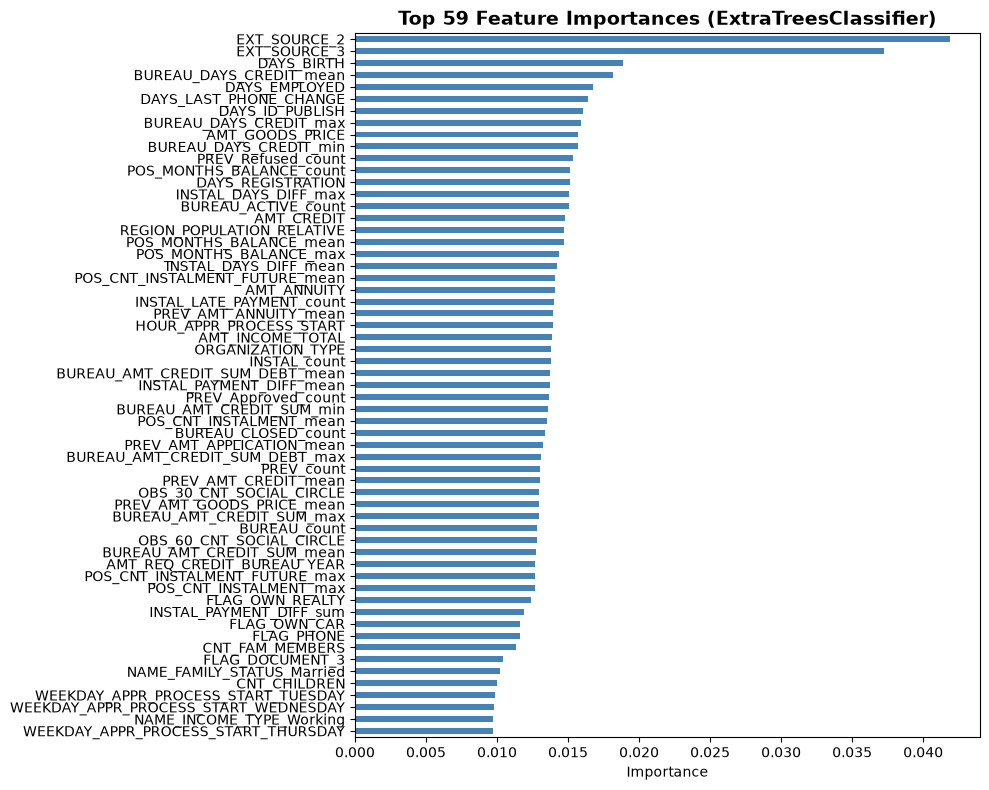

Selected 59 features contributing to 85% cumulative importance.
Top 10 selected features:
   1. EXT_SOURCE_2
   2. EXT_SOURCE_3
   3. DAYS_BIRTH
   4. BUREAU_DAYS_CREDIT_mean
   5. DAYS_EMPLOYED
   6. DAYS_LAST_PHONE_CHANGE
   7. DAYS_ID_PUBLISH
   8. BUREAU_DAYS_CREDIT_max
   9. AMT_GOODS_PRICE
  10. BUREAU_DAYS_CREDIT_min


In [24]:
feature_importance = ExtraTreesClassifier(class_weight='balanced', random_state=42)
feature_importance.fit(X_train, y_train)

importances = pd.Series(feature_importance.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

cumulative_imp = importances.cumsum() / importances.sum()
n_selected = (cumulative_imp <= 0.85).sum() + 1   # +1 to include the feature that crosses 85%
n_selected = max(n_selected, 10)  # ensure at least 10 features

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(n_selected).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'Top {n_selected} Feature Importances (ExtraTreesClassifier)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

selected_features = importances.head(n_selected).index.tolist()
print(f'Selected {n_selected} features contributing to 85% cumulative importance.')
print(f'Top 10 selected features:')
for i, feat in enumerate(selected_features[:10], 1):
    print(f'  {i:>2}. {feat}')


In [25]:
X_train_sel = X_train[selected_features]

In [26]:
X_val_sel   = X_val[selected_features]

In [27]:
X_test_sel = X_test[selected_features]

## Section 5: Modeling


### 5.1 Logistic Regression



In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, make_scorer, recall_score


In [29]:
def bias_variance_analysis(model, X_train, y_train, cv=5, model_name="Model"):
    """
    Menghitung Bias dan Variance menggunakan K-Fold Cross-Validation
    
    Bias: Error pada training set (underfitting)
    Variance: Perbedaan error antar fold (overfitting)
    """
    kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    train_scores = []
    val_scores = []
    train_errors = []
    val_errors = []
    train_variances = []
    val_variances = []
    
    for train_idx, test_idx in kfold.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]
        
        # Train model
        model.fit(X_tr, y_tr)
        
        # Predictions
        y_train_pred = model.predict(X_tr)
        y_val_pred = model.predict(X_te)
        
        # Calculate errors
        score_train = accuracy_score(y_tr, y_train_pred)
        score_val = accuracy_score(y_te, y_val_pred)
        train_error = 1 - score_train
        val_error = 1 - score_val
        train_variance = y_train_pred.var()
        val_variance = y_val_pred.var()
        
        train_scores.append(score_train)
        val_scores.append(score_val)
        train_errors.append(train_error)
        val_errors.append(val_error)
        train_variances.append(train_variance)
        val_variances.append(val_variance)
        
    
    train_scores = np.array(train_scores) 
    val_scores = np.array(val_scores)
    train_errors = np.array(train_errors)
    val_errors = np.array(val_errors)
    train_variances = np.array(train_variances)
    val_variances = np.array(val_variances)
    
    # Calculate Bias and Variance
    
    
    return {
        'model':model,
        'train_scores': train_scores,
        'val_scores': val_scores,
        'train_bias': train_errors,
        'val_bias': val_errors,
        'train_variance': train_variances,
        'val_variance': val_variances,
        'avg_train_variance': train_variances.mean(),
        'avg_val_variance': val_variances.mean(),
        'avg_train_bias': train_errors.mean(),
        'avg_val_bias': val_errors.mean()
    }

In [30]:
def plot_bias_variance_from_analysis(result, figsize=(14,5), save_path=None, show=True):
    """
    Plot hasil bias-variance berdasarkan dict keluaran dari fungsi Anda.
    Memakai keys yang ada: 'avg_train_bias'/'avg_test_bias', 'train_variance', 'test_variance'.
    """
    train_var_arr = np.asarray(result.get('train_variance', []))
    val_var_arr  = np.asarray(result.get('val_variance',  []))
    train_bias_arr  = np.asarray(result.get('train_bias',  []))
    val_bias_arr  = np.asarray(result.get('val_bias',  []))
    avg_train_score = result.get('train_scores', np.nan).mean()
    avg_val_score = result.get('val_scores', np.nan).mean()
    avg_train_bias = result.get('avg_train_bias', np.nan)
    avg_val_bias = result.get('avg_val_bias', np.nan)
    avg_train_var = result.get('avg_train_variance', np.nan)
    avg_val_var = result.get('avg_val_variance', np.nan)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].plot(train_var_arr, label='Train Variance', marker='o')
    axes[0].plot(val_var_arr, label='Validation Variance', marker='o')
    axes[0].set_title('Variance Across Folds')
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel('Variance')  
    axes[0].legend(loc="upper right")
    axes[0].grid()

    axes[1].plot(train_bias_arr, label='Train Bias', marker='o')
    axes[1].plot(val_bias_arr, label='Validation Bias', marker='o')
    axes[1].set_title('Bias Across Folds')  
    axes[1].set_xlabel('Fold')
    axes[1].set_ylabel('Bias')
    axes[1].legend(loc="upper right")
    axes[1].grid()

    plt.show()

    print(f"Average Train Bias: {avg_train_bias:.4f}")
    print(f"Average Validation Bias: {avg_val_bias:.4f}")
    print(f"Average Train Variance: {avg_train_var:.4f}")
    print(f"Average Validation Variance: {avg_val_var:.4f}")
    print(f"Average Train Score: {avg_train_score:.4f}")
    print(f"Average Validation Score: {avg_val_score:.4f}")

In [31]:
from sklearn.metrics import confusion_matrix
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    


    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc_score_rf = roc_auc_score(y_test, y_pred)
    axes[1].plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc_score_rf:.2f})')
    axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")  # diagonal line
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic (ROC)')
    axes[1].legend(loc="lower right")
    axes[1].grid()
    plt.show()

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

In [32]:
LR = LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        solver='lbfgs',
        C=1,
        random_state=42
    )

In [33]:
lr_analysis = bias_variance_analysis(LR, X_train_sel, y_train, cv=5, model_name="Logistic Regression")

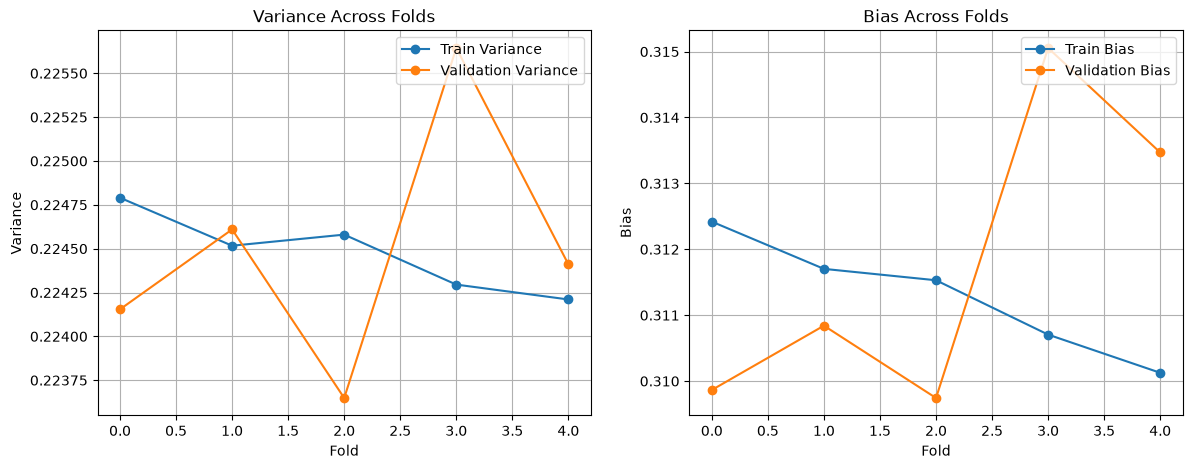

Average Train Bias: 0.3113
Average Validation Bias: 0.3118
Average Train Variance: 0.2245
Average Validation Variance: 0.2245
Average Train Score: 0.6887
Average Validation Score: 0.6882


In [34]:
plot_bias_variance_from_analysis(lr_analysis, figsize=(14,5))

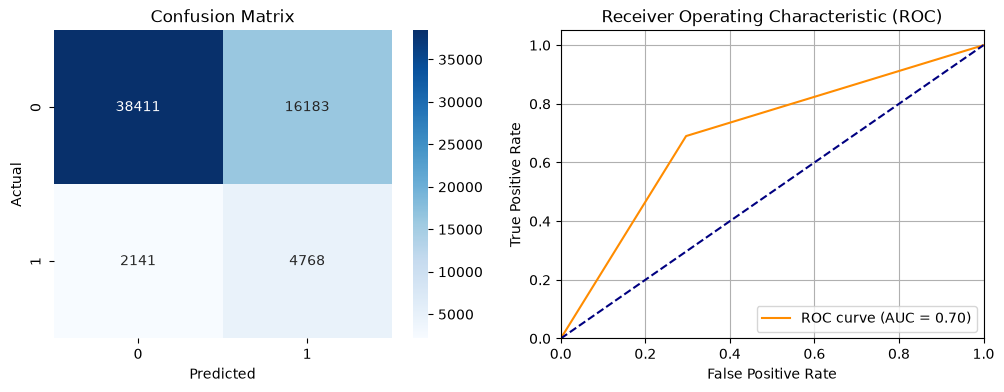

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.70      0.81     54594
           1       0.23      0.69      0.34      6909

    accuracy                           0.70     61503
   macro avg       0.59      0.70      0.57     61503
weighted avg       0.87      0.70      0.76     61503



In [35]:
evaluate_model(lr_analysis['model'], X_val_sel, y_val)

### 5.2 XGBoost

In [38]:
from xgboost import XGBClassifier

In [39]:
xgb = XGBClassifier(
        booster='gbtree',
        scale_pos_weight = 11.387150050352467,
        reg_lambda=1,
        random_state=42, # for same results across runs
    )

In [40]:
xgb_analysis = bias_variance_analysis(xgb, X_train_sel, y_train, cv=5, model_name="XGBoost")

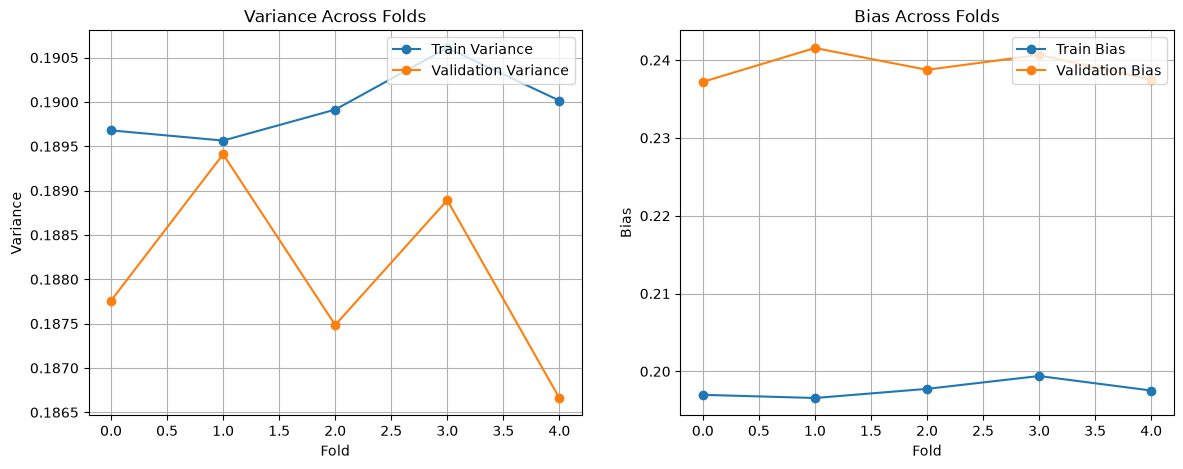

Average Train Bias: 0.1977
Average Validation Bias: 0.2391
Average Train Variance: 0.1900
Average Validation Variance: 0.1880
Average Train Score: 0.8023
Average Validation Score: 0.7609


In [41]:
plot_bias_variance_from_analysis(xgb_analysis, figsize=(14,5))

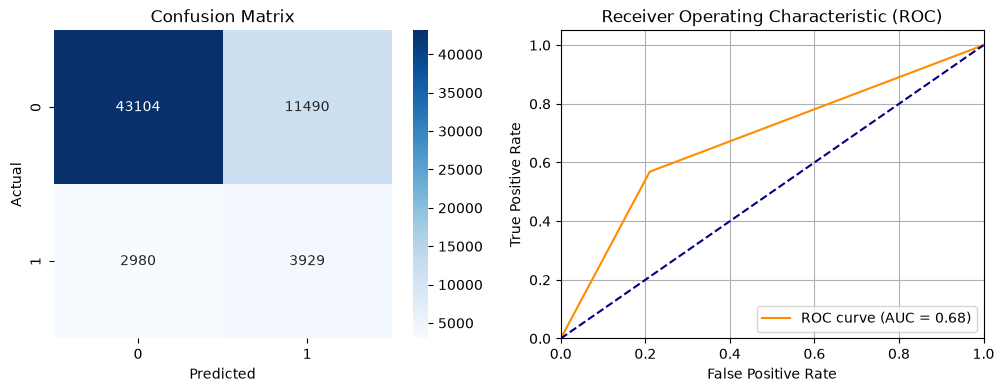

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86     54594
           1       0.25      0.57      0.35      6909

    accuracy                           0.76     61503
   macro avg       0.60      0.68      0.60     61503
weighted avg       0.86      0.76      0.80     61503



In [42]:
evaluate_model(xgb_analysis['model'], X_val_sel, y_val)

### 5.3 SMOTETomek

In [43]:
from imblearn.combine import SMOTETomek

In [44]:
st = SMOTETomek(random_state=42)
X_train_st, y_train_st = st.fit_resample(X_train_sel, y_train)

### 5.3 LR + SMOTETomek

In [45]:
LR_ST = LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        solver='lbfgs',
        C=1,
        random_state=42
    )

In [46]:
lr_st_analysis = bias_variance_analysis(LR_ST, X_train_st, y_train_st, cv=5, model_name="Logistic Regression with SMOTETomek")

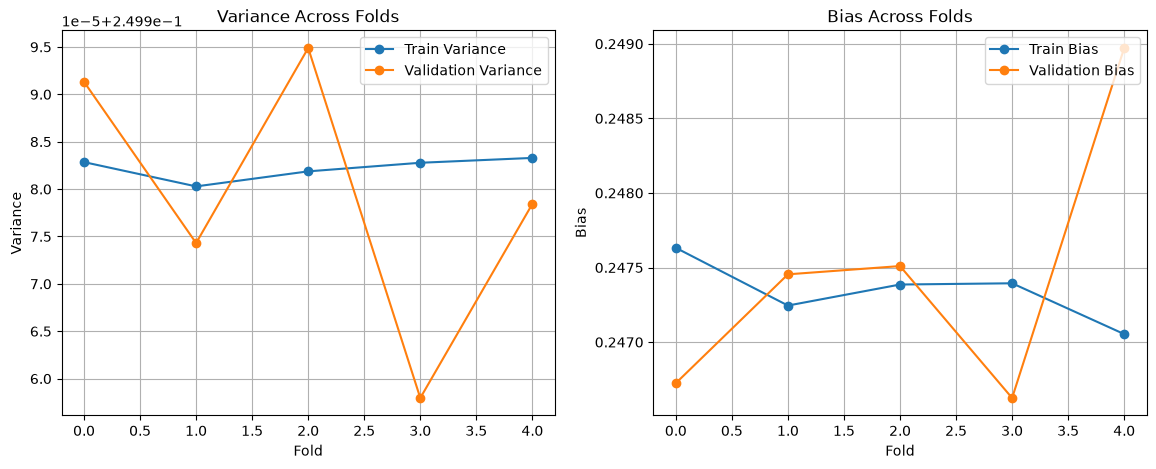

Average Train Bias: 0.2473
Average Validation Bias: 0.2475
Average Train Variance: 0.2500
Average Validation Variance: 0.2500
Average Train Score: 0.7527
Average Validation Score: 0.7525


In [47]:
plot_bias_variance_from_analysis(lr_st_analysis, figsize=(14,5))

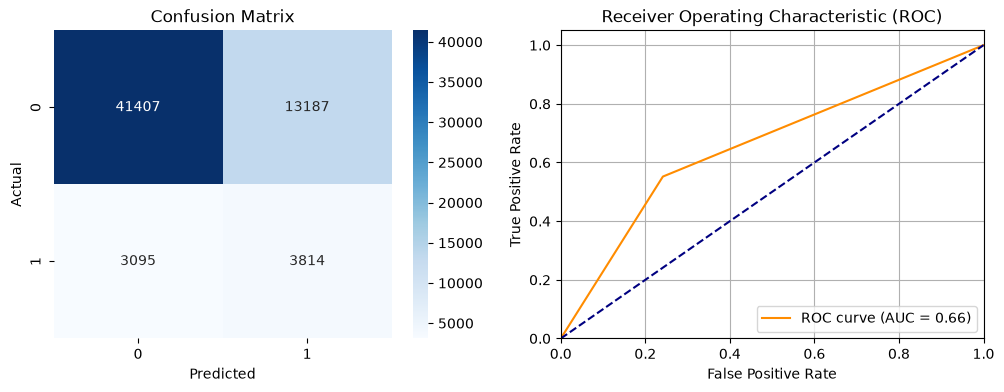

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84     54594
           1       0.22      0.55      0.32      6909

    accuracy                           0.74     61503
   macro avg       0.58      0.66      0.58     61503
weighted avg       0.85      0.74      0.78     61503



In [48]:
evaluate_model(lr_st_analysis['model'], X_val_sel, y_val)

### 5.4 XGB + SMOTETomek

In [49]:
XGB_ST = XGBClassifier(
        booster='gbtree',
        scale_pos_weight = 11.387150050352467,
        reg_lambda=1,
        random_state=42, # for same results across runs
    )

In [50]:
xgb_st_analysis = bias_variance_analysis(XGB_ST, X_train_st, y_train_st, cv=5, model_name="XGBoost with SMOTETomek")

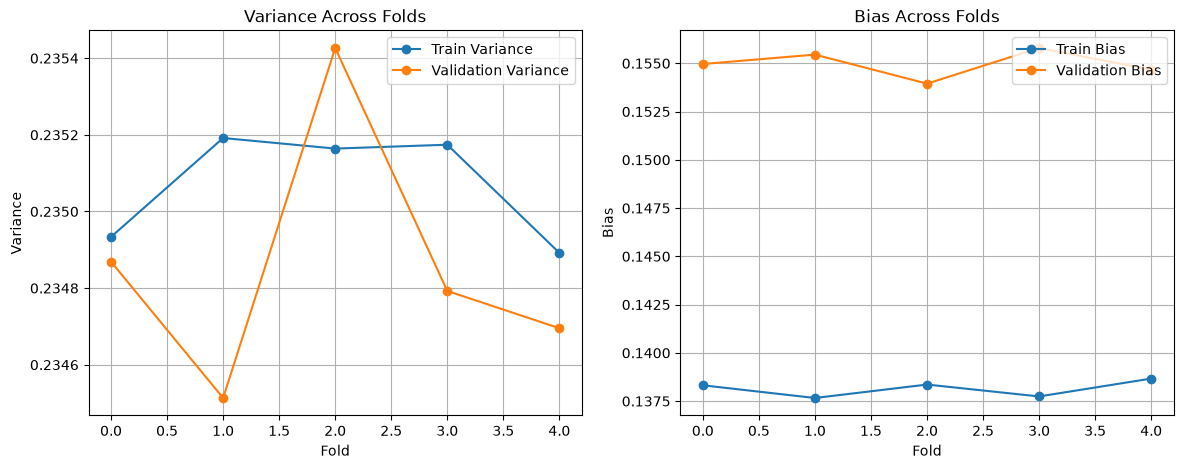

Average Train Bias: 0.1382
Average Validation Bias: 0.1550
Average Train Variance: 0.2351
Average Validation Variance: 0.2349
Average Train Score: 0.8618
Average Validation Score: 0.8450


In [51]:
plot_bias_variance_from_analysis(xgb_st_analysis, figsize=(14,5))

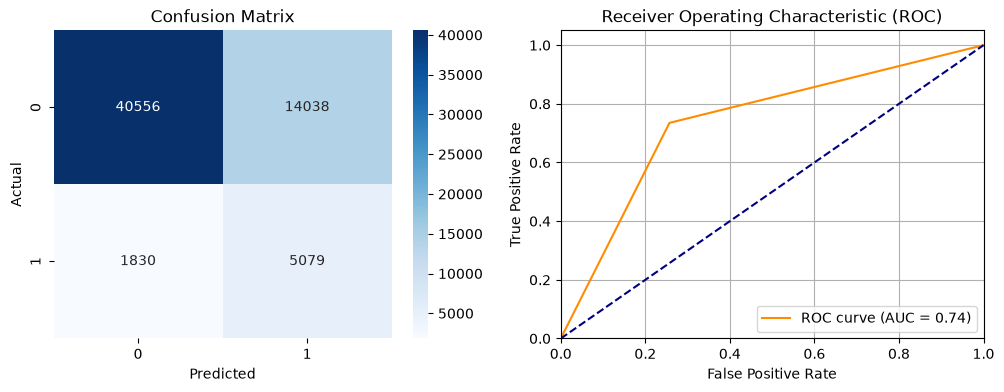

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     54594
           1       0.27      0.74      0.39      6909

    accuracy                           0.74     61503
   macro avg       0.61      0.74      0.61     61503
weighted avg       0.88      0.74      0.79     61503



In [52]:
evaluate_model(xgb_st_analysis['model'], X_val_sel, y_val)

### 5.5 LR + SMOTETomek + Bayesian Search

In [53]:
from skopt import BayesSearchCV

In [54]:
param_grid_lr = {
    'C': [1, 2, 3, 4, 5], # regularization parameter
    'penalty': ['l2'], # type of regularization
}

# Initialize Bayesian Optimization
lr_opt = BayesSearchCV(
    LogisticRegression(
        class_weight='balanced', # handle weight for imbalanced data
        random_state=42, # for same results across runs
        solver='lbfgs', # algorithm to use for optimizatio
    ),
    param_grid_lr,
    n_iter=3,
    scoring='recall',
    cv=5
)

In [55]:
lr_opt.fit(X_train_sel, y_train)

,estimator,LogisticRegre...ndom_state=42)
,search_spaces,"{'C': [1, 2, ...], 'penalty': ['l2']}"
,n_iter,3
,scoring,'recall'
,cv,5
,optimizer_kwargs,None
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True


In [56]:
print(f"val. score: {lr_opt.best_score_}")
print("Best Hyperparameters:", lr_opt.best_params_)

val. score: 0.6779034964504006
Best Hyperparameters: OrderedDict({'C': 3, 'penalty': 'l2'})


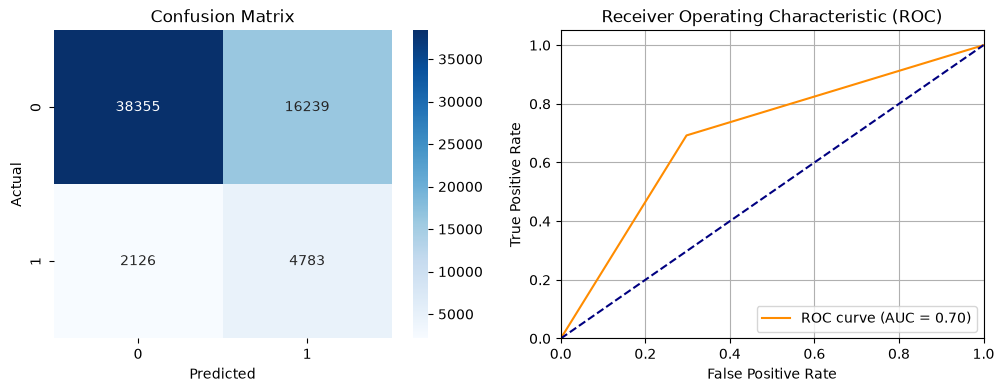

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.70      0.81     54594
           1       0.23      0.69      0.34      6909

    accuracy                           0.70     61503
   macro avg       0.59      0.70      0.57     61503
weighted avg       0.87      0.70      0.75     61503



In [57]:
evaluate_model(lr_opt, X_val_sel, y_val)

### 5.6 LR + SMOTETomek + Bayesian Search

In [58]:
param_grid_xgb = {
    'reg_lambda': [0.1, 0.5, 1, 2, 3, 4, 5],
}

# Initialize Bayesian Optimization
xgb_opt = BayesSearchCV(
    XGBClassifier(
        booster='gbtree',
        scale_pos_weight = 11.387150050352467,
        device='cuda',  # Use GPU if available
        random_state=42, # for same results across runs
    ),
    param_grid_xgb,
    n_iter=4,
    scoring='recall',
    cv=5
)

In [59]:
xgb_opt.fit(X_train_sel, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,search_spaces,"{'reg_lambda': [0.1, 0.5, ...]}"
,n_iter,4
,scoring,'recall'
,cv,5
,optimizer_kwargs,None
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True


In [60]:
print("val. score:", xgb_opt.best_score_)
print("Best Hyperparameters:", xgb_opt.best_params_)

val. score: 0.5804993482910039
Best Hyperparameters: OrderedDict({'reg_lambda': 5})


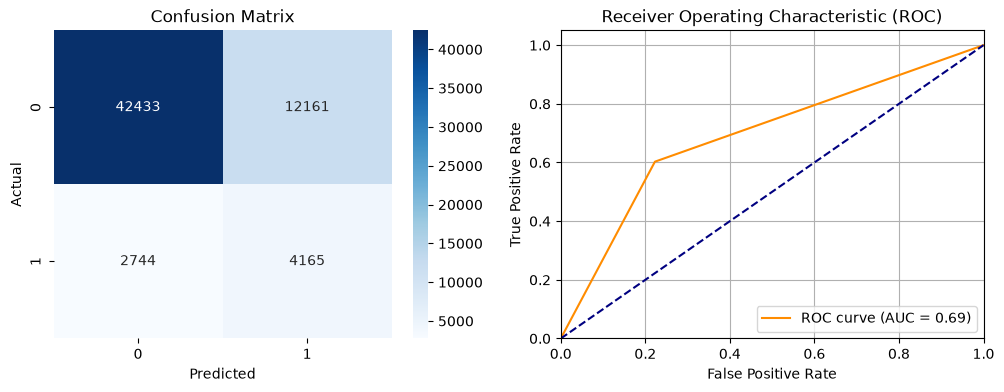

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85     54594
           1       0.26      0.60      0.36      6909

    accuracy                           0.76     61503
   macro avg       0.60      0.69      0.60     61503
weighted avg       0.86      0.76      0.80     61503



In [61]:
evaluate_model(xgb_opt, X_val_sel, y_val)

## 🧪 Model Evaluation

The best model is (**XGBoost + SMOTETomek**) to predict the `TARGET` variable (likelihood of payment difficulty).

External credit bureau scores (`EXT_SOURCE_2`, `EXT_SOURCE_3`) and applicant demographic/behavioral signals (age, employment tenure, ID/registration recency) are the strongest predictors of default risk.

### Performance Metrics

**Confusion Matrix**

|              | Predicted 0 | Predicted 1 |
|--------------|------------:|------------:|
| **Actual 0** | 40,556 | 14,038 |
| **Actual 1** | 1,830  | 5,079  |

**Classification Report**

| Class | Precision | Recall | F1-score |
|-------|----------:|-------:|---------:|
| 0 (No default) | 0.96 | 0.74 | 0.84 | 
| 1 (Default)     | 0.27 | 0.74 | 0.39 |

- **Accuracy:** 74%
- **AUC (ROC):** 74%

## 🔍 Risk Analysis Insights
<img width="693" height="589" alt="plot" src="https://github.com/user-attachments/assets/b5d49ddb-5680-4101-960a-d563c18c3fbb" />

### 1. Early Detection of Late-Payment Risk
Low external credit scores correlate strongly with payment problems early in the loan tenor. This makes external scores an effective **early warning system** for new loan applications.

### 2. Limitations of Credit Bureau History
A long credit history does not guarantee payment discipline on a new loan. Past credit experience alone is not a strong enough predictor of early-tenor repayment behavior.

## 💡 Business Recommendations

### 1. Design a Score-Based Early Intervention Program
Rather than waiting for a missed payment to occur, the collections/CRM team can use the model's risk score to proactively engage customers flagged with low external scores, for example through:

- H-3 payment reminders
- Ongoing installment education for borrowers
- Lightweight rescheduling options

The goal is to act *before* a late payment actually happens.

### 2. Independently Validate Every New Application
"Being a long-standing credit customer" should not be used as a justification for relaxing approval requirements. Long credit history has not been shown to correlate with smooth early repayment behavior. Automatic leniency policies for clients with long credit histories should be reviewed — every new application should still be evaluated using the applicant's most current external score.